In [1]:
import pandas as pd
import numpy as np

from rdkit.Chem import Draw, MolFromSmiles, ReplaceSubstructs, RemoveAllHs, FragmentOnBRICSBonds, GetMolFrags, MolToSmiles
from IPython.display import SVG

# Load Data

In [2]:
df_expl = pd.read_pickle('rf_classification_mutagenicity/df_explanation.pkl')
split = 0
df_expl = df_expl.loc[df_expl.split == split]
df_expl.head()

,dataset,split,smiles,y_true,y_pred,y_pred_proba,fragExplainer_result,fragExplainer_expected_value,fragExplainer_expected_value_logits,shap_result,shape_expected_value,frag_to_atom_ids,atom_id_to_bits
0,mutagenicity,0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1,1,0.995,{0: 7.735441472126716},0.08,-2.442337,"[0.0, 0.003672657400859738, -4.093517156434245...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{5: [203, 1750, 1873], 7: [203, 1750, 1873], 8..."
1,mutagenicity,0,CCN(CC(O)C1=CC(=O)C(=[N+]=[N-])C=C1)N=O,1,1,0.885,{0: 4.482983573353697},0.08,-2.442337,"[0.0, -0.004228411446422236, -6.82536196768523...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{4: [1, 165, 1362], 1: [80, 932, 1039], 3: [80..."
2,mutagenicity,0,C#CC1(OC(=O)CCCCCC)CCC2C3CCC4=CC(=O)CCC4C3CCC21C,0,0,0.030,"{0: -0.6003725791786283, 1: -0.019151843724327...",0.08,-2.442337,"[0.0, -0.0007230396759015667, -5.0386004301685...",0.56035,"{0: [0, 1, 2, 12, 13, 14, 15, 16, 17, 18, 19, ...","{18: [57, 292, 1380], 6: [80, 1399, 1564], 7: ..."
3,mutagenicity,0,OC1C=Cc2c(ccc3c(Br)c4ccccc4cc23)C1O,1,1,0.740,{0: 3.488301682767639},0.08,-2.442337,"[0.0, 0.004915755669061008, 5.9491886167961635...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{1: [109, 1019, 1557], 19: [127, 164, 1019], 1..."
4,mutagenicity,0,C[C@@H](O)CCC(=O)c1ccoc1,0,0,0.110,"{0: -0.41516402206040637, 1: 0.7667665147959731}",0.08,-2.442337,"[0.0, -0.014181808895611, -9.999097916079336e-...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6], 1: [7, 8, 9, 10, 11]}","{1: [1, 913, 1898], 3: [80, 739, 876], 4: [80,..."


# Simple Visualization

In [3]:

def visualize_contributions(smiles, contributions, scale=0.5):
    chargeRadii = {}
    chargeColors = {}
    highlightAtoms = []
    for i,chg in enumerate(contributions):
        # quantize and scale the charge so that we can use it to scale the highlight radii
        #chg = (10*chg//1)/10
        if abs(chg)>1e-4:
            chargeRadii[i] = abs(chg) * scale
            highlightAtoms.append(i)
            if chg>0:
                chargeColors[i] = (1,.5,.5)
            else:
                chargeColors[i] = (.5,.5,1)

    d2d = Draw.MolDraw2DSVG(550,350)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    # we need to set the highlights to be circles or we'll end up with ovals
    # that fit around the atomic symbol
    dopts.atomHighlightsAreCircles = True

    # we need to provide highlightBonds=[] here to avoid having the bonds between highlighted atoms highlighted:
    d2d.DrawMolecule(MolFromSmiles(smiles),
                     highlightAtoms=highlightAtoms,
                     highlightAtomColors=chargeColors,
                     highlightAtomRadii=chargeRadii,
                     highlightBonds=[])
    d2d.FinishDrawing()
    return SVG(d2d.GetDrawingText())

In [4]:
def get_frag_contributions_from_result_dict(smiles, results_dict, frag_to_atom_ids):
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for frag_id in range(len(results_dict.keys())):
        for atom_id in frag_to_atom_ids[frag_id]:
            contributions[atom_id] = results_dict[frag_id]
    return contributions

In [5]:
# only consider true toxic ones
df_tmp = df_expl.loc[(df_expl.y_true == 1) & (df_expl.y_pred == 1)]
df_tmp.shape

(680, 13)

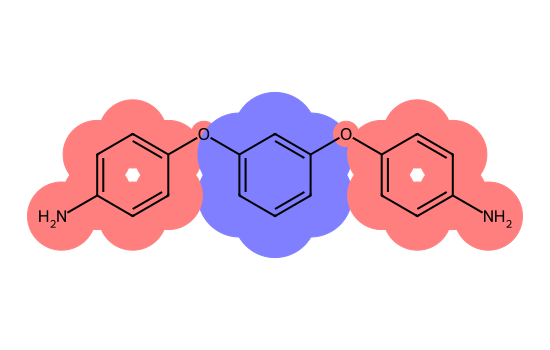

In [6]:
index = 7

# extract data from row
row = df_tmp.iloc[index]

smiles = row.smiles
y_pred_proba = row.y_pred_proba
explainer_result = row.fragExplainer_result
expected_value_logits = row.fragExplainer_expected_value_logits
frag_to_atom_ids = row.frag_to_atom_ids

contributions = get_frag_contributions_from_result_dict(smiles=row.smiles,
                                                        results_dict=row.fragExplainer_result,
                                                        frag_to_atom_ids=row.frag_to_atom_ids)

visualize_contributions(smiles=row.smiles,
                        contributions=contributions,
                        scale=0.3)

# Identify substituent with strongest contribution to mutagenicity

In [7]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned] 
    return [MolToSmiles(m) for m in frags_cleaned]

In [8]:
frag_smiles = get_BRICS_fragments_as_SMILES(row.smiles)
smiles_to_contrib = {k:v for k, v in zip(frag_smiles, row.fragExplainer_result.values())}

In [9]:
# only consider fragments with one substituent atm and with positive contributions
# we want to replace these with less toxic substituents
frags_to_remove = {k: v for k, v in smiles_to_contrib.items() if (v > 0.0) & (k.count('*') == 1)}

In [10]:
frags_to_remove

{'*c1ccc(N)cc1': np.float64(4.150389245282389)}

# get list of possible non-toxic R-groups

In [11]:
df_expl['fragments_SMILES'] = df_expl.smiles.apply(get_BRICS_fragments_as_SMILES)

In [12]:
r = df_expl.fragExplainer_result.to_list() # list of result dicts
r_ = [list(d.values()) for d in r] # turn dict into simple list
list_of_shap = [i for j in r_ for i in j] # flatten list
s = df_expl.fragments_SMILES.to_list() # list of list of smiles
list_of_smiles = [smiles for l in s for smiles in l] # flatten list

# assemble new dataframe
df_frag_single = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
# groupby SMILES, get all values and calculate mean and std
df_analysis = df_frag_single.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis['n_fragments'] = df_analysis['values'].apply(len)
df_analysis['mean'] = df_analysis['values'].apply(np.mean)
df_analysis['std'] = df_analysis['values'].apply(np.std)

In [13]:
n_appearance = 5 # minimum number of appearances in the whole dataset
df_analysis = df_analysis.loc[df_analysis.n_fragments >= n_appearance]
df_analysis.shape

(83, 5)

In [14]:
# only one attachment point
def filter_single_attachment(smiles):
    if smiles.count('*') == 1:
        return True
    else:
        return False
df_analysis = df_analysis.loc[df_analysis.smiles.apply(filter_single_attachment)]
df_analysis.shape

(61, 5)

In [15]:
# only use non-toxic R groups
df_analysis = df_analysis.loc[df_analysis['mean'] <= 0.0]
df_analysis.shape

(18, 5)

In [16]:
from rdkit.Chem import Mol
def remove_atom_map_num(mol):
    mn = Mol(mol)
    for at in mn.GetAtoms():
        at.SetAtomMapNum(0)
    return mn

def isotope_info_to_atom_map_num(mol):
    for at in mol.GetAtoms():
        if at.GetSymbol() == '*':
            info = at.GetIsotope()
            at.SetIsotope(0)
            at.SetAtomMapNum(info)
    return mol

In [17]:
from rdkit.Chem.BRICS import FindBRICSBonds, BreakBRICSBonds
from rdkit.Chem import molzipFragments


def replace_single_BRICS_substructure_in_mol(mol, smiles_pattern, smiles_replacement):
    # start by getting the bonds that are about to be cut
    brics_bonds = list(FindBRICSBonds(mol))
    # modify in such a way, that the two atoms belonging to the same broken bond have the same isotope information
    brics_bonds_mod = [(t[0], (f'{i+1}', f'{i+1}')) for i, t in enumerate(brics_bonds)]
    # now we can break the BRICS bonds
    brics_broken = BreakBRICSBonds(mol=mol,
                                bonds=brics_bonds_mod,
                                )
    # now turn all of the isotope information into AtomMapNum information
    brics_broken = isotope_info_to_atom_map_num(brics_broken)
    brics_broken_n = remove_atom_map_num(brics_broken)

    # these fragments contain the correctly labeled fragments
    fragments = GetMolFrags(mol=brics_broken,
                            asMols=True)

    # these fragments contain no map num
    # necessary to check which fragments should be replaced
    fragments_n = GetMolFrags(mol=brics_broken_n,
                            asMols=True)
    smiles_n = [MolToSmiles(f) for f in fragments_n]
    idxs_to_replace = [idx for idx, e in enumerate(smiles_n) if e == smiles_pattern]

    output_mols = []

    for idx_to_replace in idxs_to_replace:
        new_frags = ()
        for idx, frag in enumerate(fragments):
            if idx != idx_to_replace:
                new_frags += (frag, )
            else:
                # need to replace
                frag_repl = MolFromSmiles(smiles_replacement)
                # get correct Atom Map Num
                amn = max([at.GetAtomMapNum() for at in frag.GetAtoms()])
                # set correct Atom Map Num
                for at in frag_repl.GetAtoms():
                    if at.GetSymbol() == '*':
                        at.SetAtomMapNum(amn)
                new_frags += (frag_repl, )
        output_mols.append(molzipFragments(new_frags))
    return output_mols

In [18]:
mols, repl_frags, new_frags = [], [], []
replacement_frags = df_analysis.sort_values(by='mean').smiles.to_list()[:10]

for frag_to_remove in frags_to_remove.keys():
    for replacement_frag in replacement_frags:
        out_mols = replace_single_BRICS_substructure_in_mol(MolFromSmiles(smiles), frag_to_remove, replacement_frag)
        mols += out_mols
        repl_frags += [frag_to_remove] * len(out_mols)
        new_frags += [replacement_frag] * len(out_mols)

In [19]:
df_single_repl = pd.DataFrame({'mol': mols,
                               'replaced_frag': repl_frags,
                               'new_frags': new_frags})
df_single_repl['smiles'] = df_single_repl.mol.apply(MolToSmiles)
df_single_repl = df_single_repl.drop_duplicates(subset='smiles')
df_single_repl

,mol,replaced_frag,new_frags,smiles
0,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349700>,*c1ccc(N)cc1,*CC(CC)CCCC,CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1
2,<rdkit.Chem.rdchem.Mol object at 0x7f4d683491c0>,*c1ccc(N)cc1,*C(=O)C(=C)C,C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1
4,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349930>,*c1ccc(N)cc1,*CCCC,CCCCOc1cccc(Oc2ccc(N)cc2)c1
6,<rdkit.Chem.rdchem.Mol object at 0x7f4d683497e0>,*c1ccc(N)cc1,*CCCCC,CCCCCOc1cccc(Oc2ccc(N)cc2)c1
8,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349af0>,*c1ccc(N)cc1,*C(=O)O,Nc1ccc(Oc2cccc(OC(=O)O)c2)cc1
10,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349620>,*c1ccc(N)cc1,*CC(C)C,CC(C)COc1cccc(Oc2ccc(N)cc2)c1
12,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349bd0>,*c1ccc(N)cc1,*CC(=O)O,Nc1ccc(Oc2cccc(OCC(=O)O)c2)cc1
14,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349d90>,*c1ccc(N)cc1,*c1ccc(Cl)cc1,Nc1ccc(Oc2cccc(Oc3ccc(Cl)cc3)c2)cc1
16,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349e70>,*c1ccc(N)cc1,*C(C)C,CC(C)Oc1cccc(Oc2ccc(N)cc2)c1
18,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349460>,*c1ccc(N)cc1,*C1CCCCC1,Nc1ccc(Oc2cccc(OC3CCCCC3)c2)cc1


In [20]:
# load model and predict
from pickle import load
with open(f'rf_classification_mutagenicity/models/model_rfr_mutagenicity_split_{split}.pkl', 'rb') as f:
    rfc = load(f)

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

mfpgen = GetMorganGenerator(radius=2,
                            fpSize=2048,
                            )
fps = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in df_single_repl.smiles])
fps.shape

(10, 2048)

In [21]:
probas = rfc.predict_proba(fps)[:, 1]
df_single_repl['y_pred_proba'] = probas

In [22]:
df_single_repl

,mol,replaced_frag,new_frags,smiles,y_pred_proba
0,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349700>,*c1ccc(N)cc1,*CC(CC)CCCC,CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1,0.435
2,<rdkit.Chem.rdchem.Mol object at 0x7f4d683491c0>,*c1ccc(N)cc1,*C(=O)C(=C)C,C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1,0.670
4,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349930>,*c1ccc(N)cc1,*CCCC,CCCCOc1cccc(Oc2ccc(N)cc2)c1,0.625
6,<rdkit.Chem.rdchem.Mol object at 0x7f4d683497e0>,*c1ccc(N)cc1,*CCCCC,CCCCCOc1cccc(Oc2ccc(N)cc2)c1,0.570
8,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349af0>,*c1ccc(N)cc1,*C(=O)O,Nc1ccc(Oc2cccc(OC(=O)O)c2)cc1,0.655
10,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349620>,*c1ccc(N)cc1,*CC(C)C,CC(C)COc1cccc(Oc2ccc(N)cc2)c1,0.740
12,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349bd0>,*c1ccc(N)cc1,*CC(=O)O,Nc1ccc(Oc2cccc(OCC(=O)O)c2)cc1,0.580
14,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349d90>,*c1ccc(N)cc1,*c1ccc(Cl)cc1,Nc1ccc(Oc2cccc(Oc3ccc(Cl)cc3)c2)cc1,0.795
16,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349e70>,*c1ccc(N)cc1,*C(C)C,CC(C)Oc1cccc(Oc2ccc(N)cc2)c1,0.710
18,<rdkit.Chem.rdchem.Mol object at 0x7f4d68349460>,*c1ccc(N)cc1,*C1CCCCC1,Nc1ccc(Oc2cccc(OC3CCCCC3)c2)cc1,0.810


In [23]:
# now perform double replacement (only possible here because we have two negative ones)

In [ ]:
mols, repl_frags, new_frags = [], [], []
replacement_frags = df_analysis.sort_values(by='mean').smiles.to_list()[:10]

for smiles in df_single_repl.smiles:
    #print('HERE')
    for frag_to_remove in frags_to_remove.keys():
        #print('\tHERE')
        for replacement_frag in replacement_frags:
            #print('\t\tHERE')
            #print(smiles, frag_to_remove, replacement_frag)
            out_mols = replace_single_BRICS_substructure_in_mol(MolFromSmiles(smiles), frag_to_remove, replacement_frag)
            mols += out_mols
            repl_frags += [frag_to_remove] * len(out_mols)
            new_frags += [replacement_frag] * len(out_mols)

CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(CC)CCCC
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C(=O)C(=C)C
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CCCC
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CCCCC
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C(=O)O
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(C)C
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(=O)O
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *c1ccc(Cl)cc1
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C(C)C
CCCCC(CC)COc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C1CCCCC1
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(CC)CCCC
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C(=O)C(=C)C
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CCCC
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CCCCC
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *C(=O)O
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(C)C
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c1ccc(N)cc1 *CC(=O)O
C=C(C)C(=O)Oc1cccc(Oc2ccc(N)cc2)c1 *c

In [26]:
df_double_repl = pd.DataFrame({'mol': mols,
                               'replaced_frag': repl_frags,
                               'new_frags': new_frags})
df_double_repl['smiles'] = df_double_repl.mol.apply(MolToSmiles)
df_double_repl = df_double_repl.drop_duplicates(subset='smiles')
df_double_repl

,mol,replaced_frag,new_frags,smiles
0,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72880>,*c1ccc(N)cc1,*CC(CC)CCCC,CCCCC(CC)COc1cccc(OCC(CC)CCCC)c1
1,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72490>,*c1ccc(N)cc1,*C(=O)C(=C)C,C=C(C)C(=O)Oc1cccc(OCC(CC)CCCC)c1
2,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72500>,*c1ccc(N)cc1,*CCCC,CCCCOc1cccc(OCC(CC)CCCC)c1
3,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72810>,*c1ccc(N)cc1,*CCCCC,CCCCCOc1cccc(OCC(CC)CCCC)c1
4,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72420>,*c1ccc(N)cc1,*C(=O)O,CCCCC(CC)COc1cccc(OC(=O)O)c1
5,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a723b0>,*c1ccc(N)cc1,*CC(C)C,CCCCC(CC)COc1cccc(OCC(C)C)c1
6,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72960>,*c1ccc(N)cc1,*CC(=O)O,CCCCC(CC)COc1cccc(OCC(=O)O)c1
7,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72570>,*c1ccc(N)cc1,*c1ccc(Cl)cc1,CCCCC(CC)COc1cccc(Oc2ccc(Cl)cc2)c1
8,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72a40>,*c1ccc(N)cc1,*C(C)C,CCCCC(CC)COc1cccc(OC(C)C)c1
9,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a728f0>,*c1ccc(N)cc1,*C1CCCCC1,CCCCC(CC)COc1cccc(OC2CCCCC2)c1


In [27]:
fps = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in df_double_repl.smiles])
fps.shape

(55, 2048)

In [28]:
probas = rfc.predict_proba(fps)[:, 1]
df_double_repl['y_pred_proba'] = probas

In [29]:
df_double_repl

,mol,replaced_frag,new_frags,smiles,y_pred_proba
0,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72880>,*c1ccc(N)cc1,*CC(CC)CCCC,CCCCC(CC)COc1cccc(OCC(CC)CCCC)c1,0.135
1,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72490>,*c1ccc(N)cc1,*C(=O)C(=C)C,C=C(C)C(=O)Oc1cccc(OCC(CC)CCCC)c1,0.175
2,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72500>,*c1ccc(N)cc1,*CCCC,CCCCOc1cccc(OCC(CC)CCCC)c1,0.145
3,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72810>,*c1ccc(N)cc1,*CCCCC,CCCCCOc1cccc(OCC(CC)CCCC)c1,0.135
4,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72420>,*c1ccc(N)cc1,*C(=O)O,CCCCC(CC)COc1cccc(OC(=O)O)c1,0.090
5,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a723b0>,*c1ccc(N)cc1,*CC(C)C,CCCCC(CC)COc1cccc(OCC(C)C)c1,0.160
6,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72960>,*c1ccc(N)cc1,*CC(=O)O,CCCCC(CC)COc1cccc(OCC(=O)O)c1,0.080
7,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72570>,*c1ccc(N)cc1,*c1ccc(Cl)cc1,CCCCC(CC)COc1cccc(Oc2ccc(Cl)cc2)c1,0.190
8,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a72a40>,*c1ccc(N)cc1,*C(C)C,CCCCC(CC)COc1cccc(OC(C)C)c1,0.155
9,<rdkit.Chem.rdchem.Mol object at 0x7f4d62a728f0>,*c1ccc(N)cc1,*C1CCCCC1,CCCCC(CC)COc1cccc(OC2CCCCC2)c1,0.205


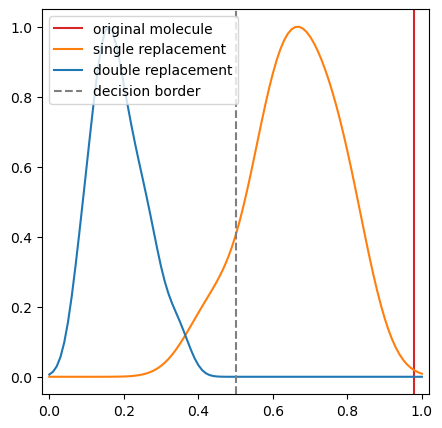

In [30]:
# visualize 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.set_xlim(-0.02, 1.02)

# original mol
axs.axvline(row.y_pred_proba, 0, 1, c='tab:red', label='original molecule')

# single replacement
x_smooth = np.linspace(0, 1, 101)
kde_single = gaussian_kde(df_single_repl.y_pred_proba)
y_single = kde_single(x_smooth)
y_single =y_single / y_single.max()
axs.plot(x_smooth, y_single, c='tab:orange', label='single replacement')

# double replacement
kde_double = gaussian_kde(df_double_repl.y_pred_proba)
y_double = kde_double(x_smooth)
y_double = y_double / y_double.max()
axs.plot(x_smooth, y_double, c='tab:blue', label='double replacement')

# decision border
axs.axvline(0.5, 0, 1, ls='--', c='tab:gray', label='decision border')

axs.legend()